In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Augmentation Details.txt
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases/auto_contrast (77).jpg
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (246).jpg
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases/sharpen (1).jpg
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (155).jpg
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases/horizontal_flip (55).jpg
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases/auto_contrast (40).jpg
/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer datase

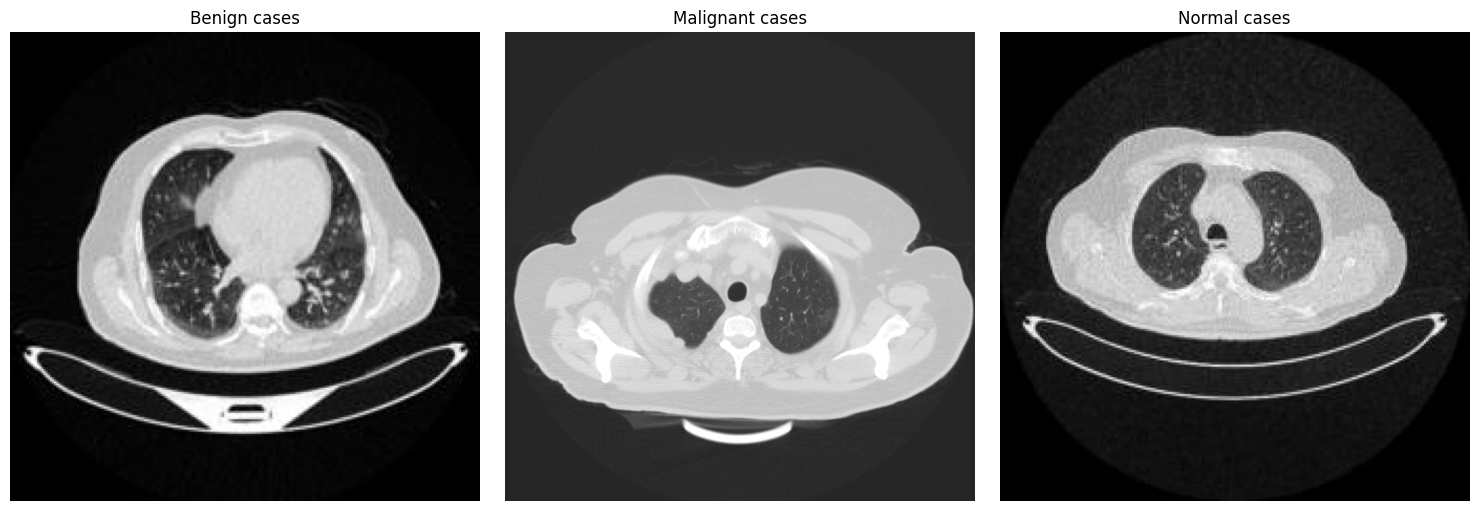

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_path = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'

benign_path = os.path.join(base_path, 'Benign cases')
malignant_path = os.path.join(base_path, 'Malignant cases')
normal_path = os.path.join(base_path, 'Normal cases')

# Function to get first image from a folder
def get_first_image(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Check for common image extensions
            return os.path.join(folder_path, filename)
    return None

# Get one image from each folder
benign_img = get_first_image(benign_path)
malignant_img = get_first_image(malignant_path)
normal_img = get_first_image(normal_path)

# Create figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Load and display Benign image
if benign_img:
    img1 = mpimg.imread(benign_img)
    ax1.imshow(img1, cmap='gray')  # Using gray colormap since these are likely CT scans
    ax1.set_title('Benign cases')
    ax1.axis('off')  # Hide axes

# Load and display Malignant image
if malignant_img:
    img2 = mpimg.imread(malignant_img)
    ax2.imshow(img2, cmap='gray')
    ax2.set_title('Malignant cases')
    ax2.axis('off')

# Load and display Normal image
if normal_img:
    img3 = mpimg.imread(normal_img)
    ax3.imshow(img3, cmap='gray')
    ax3.set_title('Normal cases')
    ax3.axis('off')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [4]:
import os
import shutil
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
random.seed(42) 

original_base = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
benign_dir = os.path.join(original_base, 'Benign cases')
malignant_dir = os.path.join(original_base, 'Malignant cases')
normal_dir = os.path.join(original_base, 'Normal cases')
 
BASE_DIR = '/kaggle/working/lung_cancer_split'
train_dir = os.path.join(BASE_DIR, 'train')
validation_dir = os.path.join(BASE_DIR, 'validation')

for dir_path in [os.path.join(train_dir, cls) for cls in ['benign', 'malignant', 'normal']] + \
                [os.path.join(validation_dir, cls) for cls in ['benign', 'malignant', 'normal']]:
    os.makedirs(dir_path, exist_ok=True)

def count_images(directory):
    return len([f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])


print("Original counts:")
print(f"Benign: {count_images(benign_dir)}")
print(f"Malignant: {count_images(malignant_dir)}")
print(f"Normal: {count_images(normal_dir)}")

Original counts:
Benign: 1200
Malignant: 1201
Normal: 1208


In [6]:
def split_and_copy(src_dir, train_dest, val_dest, train_ratio=0.8):
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(files)
    split_idx = int(len(files) * train_ratio)
    train_files, val_files = files[:split_idx], files[split_idx:]
    
    for f in train_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_dest, f))
    for f in val_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(val_dest, f))
    
    return len(train_files), len(val_files)

# Perform the split
benign_train_count, benign_val_count = split_and_copy(benign_dir, 
                                                     os.path.join(train_dir, 'benign'),
                                                     os.path.join(validation_dir, 'benign'))
malignant_train_count, malignant_val_count = split_and_copy(malignant_dir,
                                                           os.path.join(train_dir, 'malignant'),
                                                           os.path.join(validation_dir, 'malignant'))
normal_train_count, normal_val_count = split_and_copy(normal_dir,
                                                     os.path.join(train_dir, 'normal'),
                                                     os.path.join(validation_dir, 'normal'))

print("\nAfter splitting:")
print(f"Benign - Train: {benign_train_count}, Validation: {benign_val_count}")
print(f"Malignant - Train: {malignant_train_count}, Validation: {malignant_val_count}")
print(f"Normal - Train: {normal_train_count}, Validation: {normal_val_count}")



After splitting:
Benign - Train: 960, Validation: 240
Malignant - Train: 960, Validation: 241
Normal - Train: 966, Validation: 242


Found 2886 images belonging to 3 classes.
Found 723 images belonging to 3 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

...

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.3303 - loss: 1.1340 - val_accuracy: 0.3807 - val_loss: 1.0973
Epoch 2/20
 1/90 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2812 - loss: 1.0967

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2812 - loss: 1.0967 - val_accuracy: 0.1053 - val_loss: 1.1132
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.3645 - loss: 1.0982 - val_accuracy: 0.3778 - val_loss: 1.0945
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 190us/step - accuracy: 0.4688 - loss: 1.0878 - val_accuracy: 0.3684 - val_loss: 1.0956
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.3955 - loss: 1.0899 - val_accuracy: 0.4446 - val_loss: 1.0501
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 203us/step - accuracy: 0.5000 - loss: 1.0041 - val_accuracy: 0.2105 - val_loss: 1.1606
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.4348 - loss: 1.0713 - val_accuracy: 0.4574 - val_loss: 1.0127
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 184us/step - accuracy: 0.4062 - loss: 0.9956 - val_accuracy: 0.3684 - val_loss: 1.1070
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.4424 - loss: 1.0344 - val_accuracy: 0.4489 - v

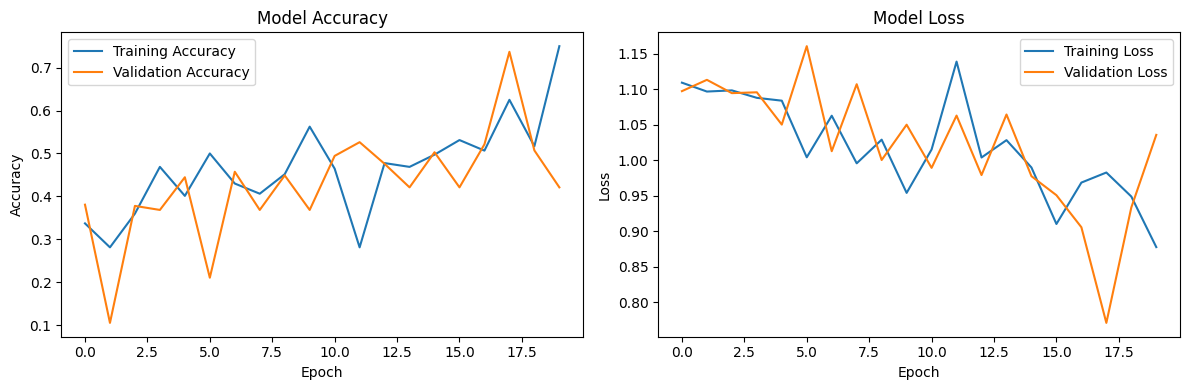

In [7]:
warnings.filterwarnings("ignore", category=UserWarning, message="Your `PyDataset` class should call")
warnings.filterwarnings("ignore", category=UserWarning, message="Your input ran out of data")

# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

# Build the CNN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    verbose=1
)

# Plot training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Found 2886 images belonging to 3 classes.
Found 723 images belonging to 3 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_98 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_99 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_100 (Conv2D)                  │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_101 (Conv2D)                  │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 202ms/step - accuracy: 0.3489 - loss: 4.0703 - val_accuracy: 0.3281 - val_loss: 1.1240 - learning_rate: 0.0010
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3438 - loss: 1.1295 - val_accuracy: 0.4737 - val_loss: 1.1179 - learning_rate: 0.0010
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.3231 - loss: 1.1105 - val_accuracy: 0.3466 - val_loss: 1.0991 - learning_rate: 0.0010
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step - accuracy: 0.2812 - loss: 1.0996 - val_accuracy: 0.2632 - val_loss: 1.1000 - learning_rate: 0.0010
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - accuracy: 0.3191 - loss: 1.0994 - val_accuracy: 0.3381 - val_loss: 1.0987 - learning_rate: 0.0010
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 204us/step - accuracy: 0.3750 - loss: 1.0987 - val_accuracy: 0.2105 - val_loss: 1.0993 - learning_rate: 0.0010
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.3120 - loss: 1.0988 

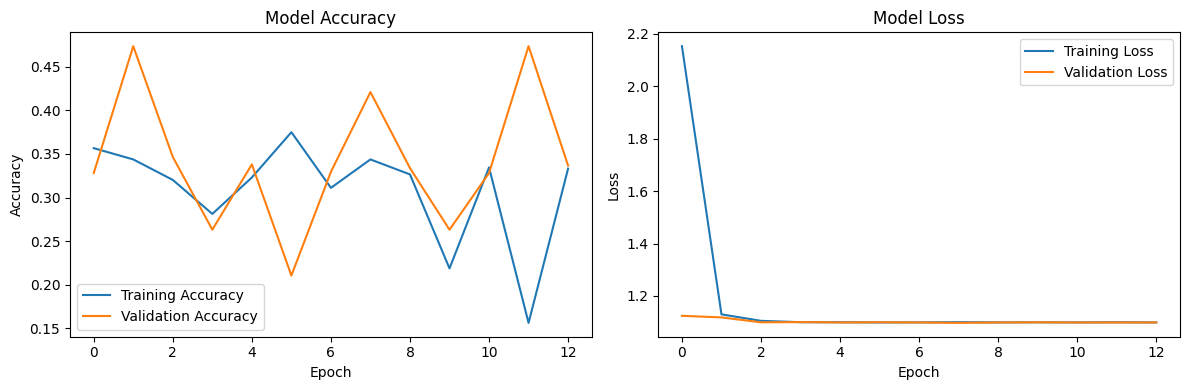

In [10]:
import warnings 
# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Your `PyDataset` class should call")
warnings.filterwarnings("ignore", category=UserWarning, message="Your input ran out of data")

# Set random seed for reproducibility
random.seed(42)

# Define paths (assuming these are already set up from your previous runs)
train_dir = '/kaggle/working/lung_cancer_split/train'
validation_dir = '/kaggle/working/lung_cancer_split/validation'

# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

# Calculate exact steps
train_steps = max(1, train_generator.samples // train_generator.batch_size)
val_steps = max(1, validation_generator.samples // validation_generator.batch_size)

# Build the improved CNN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.6),  # Increased from 0.5 to 0.6 for more regularization
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),  # Added L2 regularization
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
])

# Compile the model with Adam optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Define callbacks for early stopping and learning rate reduction
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,  # Stop after 5 epochs of no improvement
        restore_best_weights=True,  # Return the best model
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,  # Reduce LR by 20% when triggered
        patience=3,  # Trigger after 3 epochs of no improvement
        min_lr=1e-6,  # Minimum learning rate
        verbose=1
    )
]

# Train the model with callbacks
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=30,  # Increased to 30 to give room for early stopping
    validation_data=validation_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

# Plot training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Last layer output shape: (None, 7, 7, 768)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ inception_v3 (Functional)            │ (None, 3, 3, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1024)                │      18,875,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │           3,075 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,681,251 (155.19 MB)

 Trainable params: 18,878,467 (72.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Found 2886 images belonging to 3 classes.
Found 723 images belonging to 3 classes.
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.4511 - loss: 5.0611 - val_accuracy: 0.5824 - val_loss: 0.8758
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5625 - loss: 1.0478 - val_accuracy: 0.5263 - val_loss: 1.3991
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.5554 - loss: 0.9673 - val_accuracy: 0.6591 - val_loss: 0.7374
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.6875 - loss: 0.6199 - val_accuracy: 0.6316 - val_loss: 0.7988
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6147 - loss: 0.8598 - val_accuracy: 0.6278 - val_loss: 0.8034
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - accuracy: 0.4688 - loss: 1.0655 - val_accuracy: 0.5263 - val_loss: 0.9942
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6361 - loss: 0.7890 - val_accuracy: 0.6605 - val_loss: 0.6863
Epoch 8/20
90/90 ━━━━━━━━

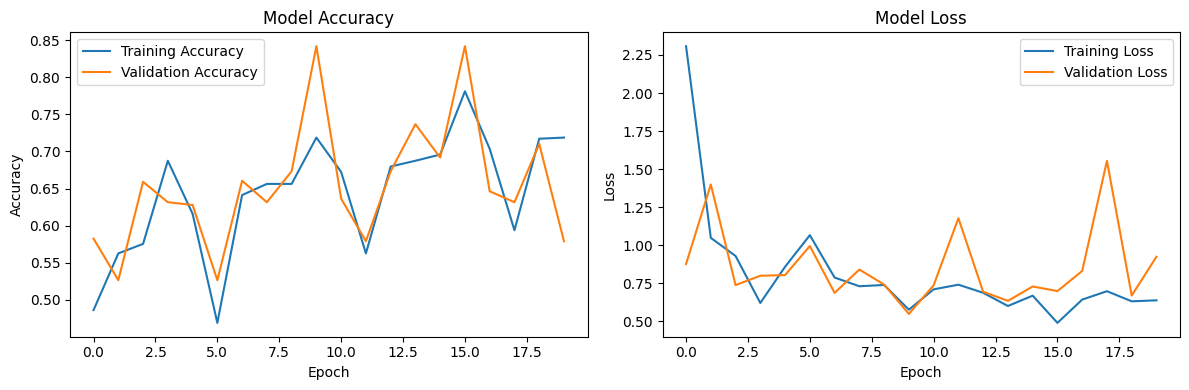

In [8]:

# Fetch pre-trained InceptionV3 weights
local_weights_file = tf.keras.utils.get_file(
    "inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5",
    "https://storage.googleapis.com/mledu-datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5",
    cache_subdir='models'
)

# Initialize InceptionV3 base model
pre_trained_model = tf.keras.applications.InceptionV3(
    input_shape=(150, 150, 3),
    include_top=False,
    weights=None
)

# Load the pre-trained weights
pre_trained_model.load_weights(local_weights_file)

# Freeze the layers
for layer in pre_trained_model.layers:
    layer.trainable = False

# Use 'mixed7' as the last layer
last_layer = pre_trained_model.get_layer('mixed7')
print('Last layer output shape:', last_layer.output.shape)
last_output = last_layer.output

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# Build the model
inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.inception_v3.preprocess_input(x)  # InceptionV3-specific preprocessing
x = pre_trained_model(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(3, activation='softmax')(x)  # 3 classes

model_with_aug = tf.keras.Model(inputs, x)

# Compile the model
model_with_aug.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss='categorical_crossentropy',  # For 3 classes
    metrics=['accuracy']
)

model_with_aug.summary()

# Create data generators
train_datagen = ImageDataGenerator()  # Preprocessing handled in model
val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

# Calculate steps
train_steps = max(1, train_generator.samples // train_generator.batch_size)
val_steps = max(1, validation_generator.samples // validation_generator.batch_size)

# Train the model
EPOCHS = 20
history = model_with_aug.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=val_steps,
    verbose=1
)

# Plot training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()